# **Goal:** --> Apply K-Means clustering on RFM , validate optimal clusters, assign business labels, and produce 5  publication-ready visualisations.

# Dataset load and setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# Consistent colours for 4 clusters
CLUSTER_COLORS = {
    'Champions'       : '#2ECC71',
    'Core Regulars'   : '#3498DB',
    'Occasional'      : '#F39C12',
    'Dormant'         : '#E74C3C',
}

rfm = pd.read_csv('./data/02_rfm.csv')
print(f'Loaded: {rfm.shape[0]:,} rows × {rfm.shape[1]} columns')
rfm[['Recency','Frequency','Monetary']].describe().round(2)

Loaded: 7,903 rows × 10 columns


,Recency,Frequency,Monetary
count,7903.00,7903.00,7903.00
mean,159.01,4.37,742.16
std,147.06,2.05,827.18
min,1.00,1.00,1.24
25%,47.00,3.00,215.88
50%,115.00,4.00,494.45
75%,226.00,6.00,972.46
max,729.00,13.00,13885.10


# Feature Preparation

We cluster on the **raw R, F, M values** (not the 1–5 scores — those already compress the signal).

Two transformations before scaling:
1. **Log-transform Monetary** (`log1p`) — removes right-skew from high spenders
2. **StandardScaler** — zero mean, unit variance so Recency doesn't dominate by magnitude


In [14]:
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
X['Monetary'] = np.log1p(X['Monetary'])   # log1p handles any zeros cleanly

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('After log-transform + StandardScaler:')
print(pd.DataFrame(X_scaled, columns=['Recency_s','Frequency_s','Monetary_s']).describe().round(3))

After log-transform + StandardScaler:
       Recency_s  Frequency_s  Monetary_s
count    7903.00      7903.00     7903.00
mean        0.00         0.00       -0.00
std         1.00         1.00        1.00
min        -1.07        -1.64       -4.43
25%        -0.76        -0.67       -0.57
50%        -0.30        -0.18        0.13
75%         0.46         0.80        0.70
max         3.88         4.21        2.94


# Optimal k

Two complementary methods:
- **Elbow method** — plot inertia vs k; look for the point where gain from adding a cluster drops sharply
- **Silhouette score** — measures how well each point fits its own cluster vs neighbours (higher = better separation)

Both are computed for k = 2 → 10.


In [15]:
K_RANGE  = range(2, 11)
inertias, silhouettes = [], []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

print(f"{'k':>3} | {'Inertia':>10} | {'Silhouette':>10} | {'Δ Inertia':>10}")
print('-' * 44)
for i, (k, iner, sil) in enumerate(zip(K_RANGE, inertias, silhouettes)):
    delta = f'{inertias[i-1] - iner:>8.0f}' if i > 0 else '        —'
    print(f'{k:>3} | {iner:>10.1f} | {sil:>10.4f} | {delta}')

  k |    Inertia | Silhouette |  Δ Inertia
--------------------------------------------
  2 |    14364.9 |     0.3501 |         —
  3 |    10806.6 |     0.3080 |     3558
  4 |     8855.7 |     0.2764 |     1951
  5 |     7468.1 |     0.2817 |     1388
  6 |     6619.9 |     0.2612 |      848
  7 |     5997.4 |     0.2598 |      623
  8 |     5506.3 |     0.2560 |      491
  9 |     5036.9 |     0.2635 |      469
 10 |     4649.6 |     0.2609 |      387


### Elbow + Silhouette Curves

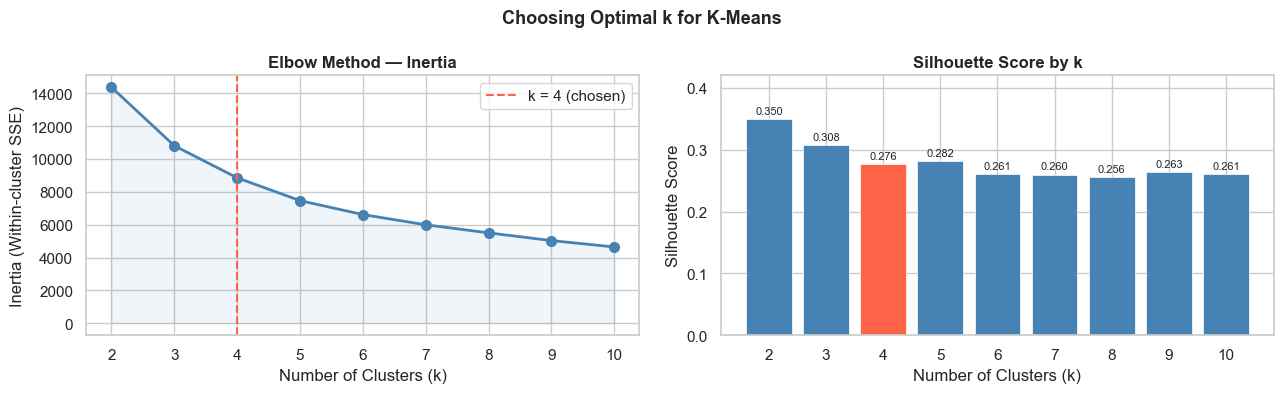

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Choosing Optimal k for K-Means', fontsize=13, fontweight='bold')

ks = list(K_RANGE)

# Elbow
ax1.plot(ks, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
ax1.axvline(4, color='tomato', linestyle='--', linewidth=1.5, label='k = 4 (chosen)')
ax1.fill_between(ks, inertias, alpha=0.08, color='steelblue')
ax1.set_title('Elbow Method — Inertia', fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster SSE)')
ax1.set_xticks(ks)
ax1.legend()

# Silhouette
bar_colors = ['tomato' if k == 4 else 'steelblue' for k in ks]
ax2.bar(ks, silhouettes, color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.set_title('Silhouette Score by k', fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(ks)
ax2.set_ylim(0, max(silhouettes) * 1.2)
for i, (k, s) in enumerate(zip(ks, silhouettes)):
    ax2.text(k, s + 0.005, f'{s:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


# Final K-Means — k = 4

**Why k = 4?**
- The elbow bends sharply between k=3 and k=4 (Δ inertia drops from ~3,558 to ~1,951 to ~1,388)
- Silhouette peaks at k=2 (0.35) but that's too coarse for business use
- k=4 delivers 4 interpretable tiers: high-value actives, core regulars, occasionals, and dormant — actionable for a marketing team
- Adding a 5th cluster splits the 'occasional' group without adding a distinct business identity


In [17]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster_Raw'] = km_final.fit_predict(X_scaled)

# Profile each cluster by mean RFM to assign names
profile = rfm.groupby('Cluster_Raw')[['Recency','Frequency','Monetary','RFM_Score']].mean().round(1)
profile['n'] = rfm['Cluster_Raw'].value_counts().sort_index()
print('=== RAW CLUSTER PROFILES ===')
print(profile.sort_values('RFM_Score', ascending=False))

=== RAW CLUSTER PROFILES ===
             Recency  Frequency  Monetary  RFM_Score     n
Cluster_Raw                                               
0              79.30       7.00   1397.30      12.70  2007
3             121.80       4.20    745.20       9.50  3304
2             129.90       2.60    124.20       6.10  1430
1             438.40       2.40    362.60       4.80  1162


# Assign Business Labels

Clusters are ranked by composite RFM_Score and named accordingly:

| Cluster | Avg Recency | Avg Freq | Avg Monetary | Label |
|---|---|---|---|---|
| Highest RFM | ~79 days | ~7.0 orders | ₹1,397 | **Champions** |
| 2nd | ~122 days | ~4.2 orders | ₹745 | **Core Regulars** |
| 3rd | ~130 days | ~2.6 orders | ₹124 | **Occasional** |
| Lowest RFM | ~438 days | ~2.4 orders | ₹363 | **Dormant** |


In [18]:
cluster_ranking = (
    rfm.groupby('Cluster_Raw')['RFM_Score']
       .mean()
       .sort_values(ascending=False)
       .index
       .tolist()
)

LABEL_MAP = {
    cluster_ranking[0]: 'Champions',
    cluster_ranking[1]: 'Core Regulars',
    cluster_ranking[2]: 'Occasional',
    cluster_ranking[3]: 'Dormant',
}

rfm['Cluster'] = rfm['Cluster_Raw'].map(LABEL_MAP)

print('=== FINAL CLUSTER DISTRIBUTION ===')
for name in ['Champions','Core Regulars','Occasional','Dormant']:
    n   = (rfm['Cluster'] == name).sum()
    pct = n / len(rfm) * 100
    avg_m = rfm[rfm['Cluster'] == name]['Monetary'].mean()
    avg_r = rfm[rfm['Cluster'] == name]['Recency'].mean()
    print(f'  {name:<18} {n:>5,} customers ({pct:.1f}%)  |  Avg Recency: {avg_r:.0f}d  |  Avg Spend: ₹{avg_m:,.0f}')

=== FINAL CLUSTER DISTRIBUTION ===
  Champions          2,007 customers (25.4%)  |  Avg Recency: 79d  |  Avg Spend: ₹1,397
  Core Regulars      3,304 customers (41.8%)  |  Avg Recency: 122d  |  Avg Spend: ₹745
  Occasional         1,430 customers (18.1%)  |  Avg Recency: 130d  |  Avg Spend: ₹124
  Dormant            1,162 customers (14.7%)  |  Avg Recency: 438d  |  Avg Spend: ₹363


# Visualisations

## 1.PCA Scatter

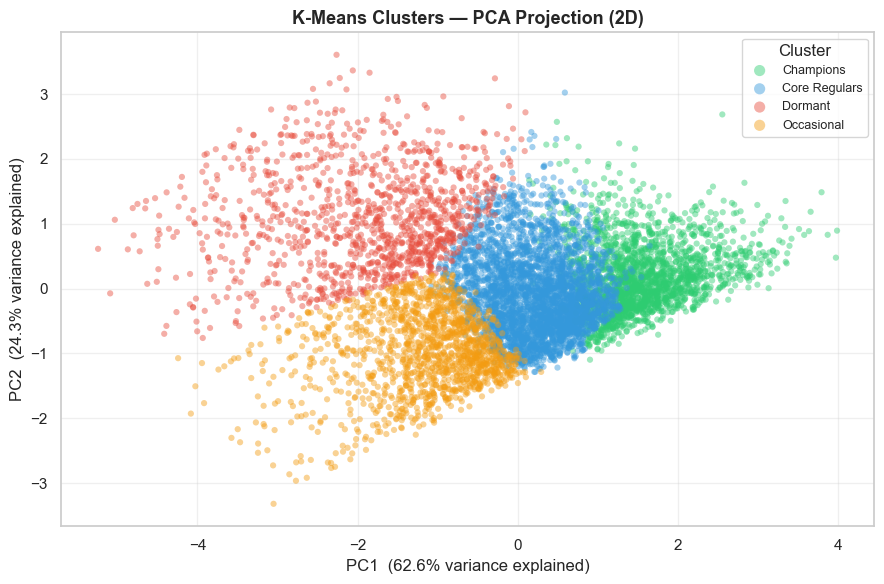

Variance explained by PC1+PC2: 86.9%


In [19]:
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_scaled)
rfm['PCA1'] = X_pca[:, 0]
rfm['PCA2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
for name, grp in rfm.groupby('Cluster'):
    ax.scatter(grp['PCA1'], grp['PCA2'],
               label=name, color=CLUSTER_COLORS[name],
               alpha=0.45, s=20, edgecolors='none')

ax.set_title('K-Means Clusters — PCA Projection (2D)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')
ax.legend(title='Cluster', fontsize=9, markerscale=1.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')

## 2. Snake / Profile Plot

Shows the normalised mean of each RFM dimension per cluster — makes differences in profile shape immediately visible.


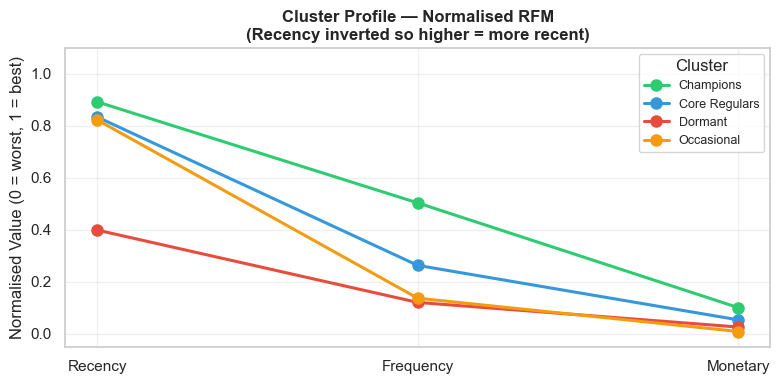

In [20]:
# Normalise each raw feature 0–1 for visual comparison
features = ['Recency', 'Frequency', 'Monetary']
rfm_norm = rfm.copy()
for col in features:
    rfm_norm[col] = (rfm[col] - rfm[col].min()) / (rfm[col].max() - rfm[col].min())

# Recency is inverted (lower = better), flip it so 'better' = higher on chart
rfm_norm['Recency'] = 1 - rfm_norm['Recency']

snake = rfm_norm.groupby('Cluster')[features].mean()

fig, ax = plt.subplots(figsize=(8, 4))
for name, row in snake.iterrows():
    ax.plot(features, row.values, 'o-', label=name,
            color=CLUSTER_COLORS[name], linewidth=2.2, markersize=8)

ax.set_title('Cluster Profile — Normalised RFM\n(Recency inverted so higher = more recent)', fontweight='bold')
ax.set_ylabel('Normalised Value (0 = worst, 1 = best)')
ax.set_ylim(-0.05, 1.1)
ax.legend(title='Cluster', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.Cluster Size & Avg Spend

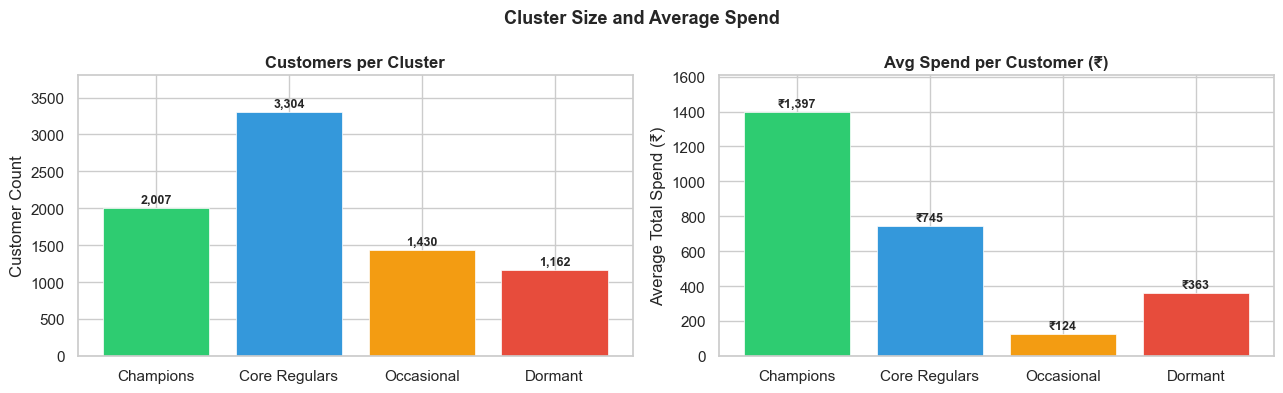

In [21]:
order = ['Champions', 'Core Regulars', 'Occasional', 'Dormant']

counts   = rfm['Cluster'].value_counts().reindex(order)
avg_mon  = rfm.groupby('Cluster')['Monetary'].mean().reindex(order)
colors   = [CLUSTER_COLORS[c] for c in order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Cluster Size and Average Spend', fontsize=13, fontweight='bold')

# Left — customer count
bars1 = ax1.bar(order, counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Customers per Cluster', fontweight='bold')
ax1.set_ylabel('Customer Count')
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 30, f'{int(h):,}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylim(0, counts.max() * 1.15)

# Right — avg monetary
bars2 = ax2.bar(order, avg_mon.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_title('Avg Spend per Customer (₹)', fontweight='bold')
ax2.set_ylabel('Average Total Spend (₹)')
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 10, f'₹{h:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylim(0, avg_mon.max() * 1.15)

plt.tight_layout()
plt.show()

## 4.Cluster × RFM Segment Cross-Tab

Shows how the data-driven K-Means clusters align with the rule-based RFM segments from Phase 2. Strong diagonal overlap validates both approaches.


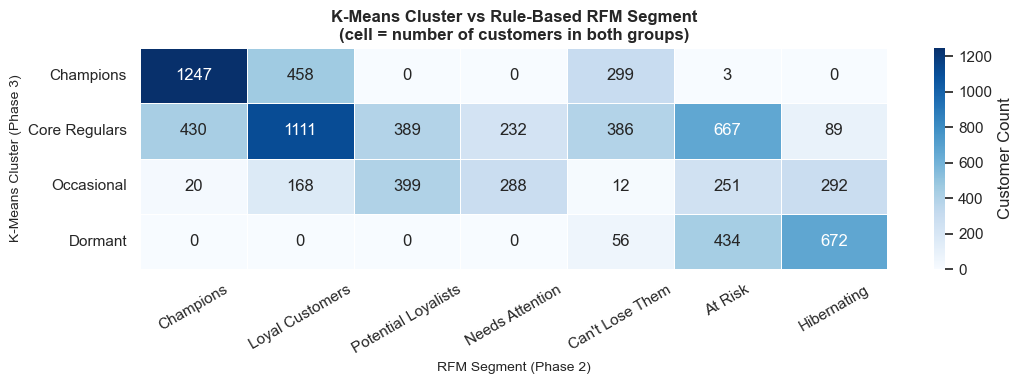

In [22]:
cross = pd.crosstab(rfm['Cluster'], rfm['Segment'])
# Reorder both axes for readability
col_order = ['Champions','Loyal Customers','Potential Loyalists',
             'Needs Attention',"Can't Lose Them",'At Risk','Hibernating']
row_order  = ['Champions','Core Regulars','Occasional','Dormant']
cross = cross.reindex(index=row_order, columns=col_order, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    cross, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Customer Count'},
    ax=ax
)
ax.set_title('K-Means Cluster vs Rule-Based RFM Segment\n(cell = number of customers in both groups)',
             fontweight='bold')
ax.set_xlabel('RFM Segment (Phase 2)', fontsize=10)
ax.set_ylabel('K-Means Cluster (Phase 3)', fontsize=10)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Cluster Summary & Strategy

In [23]:
summary = rfm.groupby('Cluster').agg(
    Customers    = ('customer_id', 'count'),
    Avg_Recency  = ('Recency',     'mean'),
    Avg_Frequency= ('Frequency',   'mean'),
    Avg_Monetary = ('Monetary',    'mean'),
    Total_Revenue= ('Monetary',    'sum'),
).round(1).reindex(['Champions','Core Regulars','Occasional','Dormant'])

summary['Pct_Customers'] = (summary['Customers'] / len(rfm) * 100).round(1)
summary['Pct_Revenue']   = (summary['Total_Revenue'] / rfm['Monetary'].sum() * 100).round(1)

strategies = {
    'Champions'    : '🏆 VIP rewards, early access, referral programme',
    'Core Regulars': '💚 Loyalty points, upsell premium categories',
    'Occasional'   : '🔵 Personalised recs, first-purchase-of-category offers',
    'Dormant'      : '🔴 Win-back campaign, aggressive discount, sunset after 2 no-responses',
}

print('=== CLUSTER STRATEGY BRIEF ===\n')
for name in ['Champions','Core Regulars','Occasional','Dormant']:
    row = summary.loc[name]
    print(f"{name}  ({int(row['Customers']):,} customers | {row['Pct_Revenue']:.1f}% of revenue)")
    print(f"  Avg Recency: {row['Avg_Recency']:.0f}d  |  Avg Freq: {row['Avg_Frequency']:.1f}  |  Avg Spend: ₹{row['Avg_Monetary']:,.0f}")
    print(f"  Strategy: {strategies[name]}\n")

=== CLUSTER STRATEGY BRIEF ===

Champions  (2,007 customers | 47.8% of revenue)
  Avg Recency: 79d  |  Avg Freq: 7.0  |  Avg Spend: ₹1,397
  Strategy: 🏆 VIP rewards, early access, referral programme

Core Regulars  (3,304 customers | 42.0% of revenue)
  Avg Recency: 122d  |  Avg Freq: 4.2  |  Avg Spend: ₹745
  Strategy: 💚 Loyalty points, upsell premium categories

Occasional  (1,430 customers | 3.0% of revenue)
  Avg Recency: 130d  |  Avg Freq: 2.6  |  Avg Spend: ₹124
  Strategy: 🔵 Personalised recs, first-purchase-of-category offers

Dormant  (1,162 customers | 7.2% of revenue)
  Avg Recency: 438d  |  Avg Freq: 2.4  |  Avg Spend: ₹363
  Strategy: 🔴 Win-back campaign, aggressive discount, sunset after 2 no-responses



In [24]:
import os
os.makedirs('./data', exist_ok=True)

# Drop helper columns before saving
out = rfm.drop(columns=['Cluster_Raw', 'PCA1', 'PCA2'], errors='ignore')
out.to_csv('./data/03_clustered.csv', index=False)

summary.reset_index().to_csv('./data/03_cluster_summary.csv', index=False)

print('✓  Saved → data/03_clustered.csv')
print(f'   Shape  : {out.shape[0]:,} rows × {out.shape[1]} columns')
print(f'   Columns: {out.columns.tolist()}')

✓  Saved → data/03_clustered.csv
   Shape  : 7,903 rows × 11 columns
   Columns: ['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Label', 'Segment', 'Cluster']
